*  DSC540-T302 Data Preparation (2261-1)
*  Term Project: Milestone 5
*  Charles Sarratt

**Title:** Integrating IMDb, Wikipedia, and OMDb: A Multi-Source Analysis of Film Success  
**Milestone:** Merging IMDb, Wikipedia, and OMDb Data and Visualizing Results
**Author:** Charles Sarratt

This milestone loads the three cleaned datasets from the earlier milestones
(IMDb flat file, Wikipedia highest grossing films, and OMDb API data), stores
them in a SQLite database, joins them into a consolidated dataset using SQL,
and then creates five visualizations to explore the relationships in the data.

The three cleaned input files used here are:

- `cleaned_imdb_movies.csv`  (flat file)
- `cleaned_wikipedia_films.csv`  (website)
- `cleaned_api_movies.csv`  (API)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

print("Libraries loaded.")

Libraries loaded.


## Step 1 - Load the three cleaned datasets

Load the cleaned flat file, website, and API datasets that were produced in
Milestones 2, 3, and 4. These CSV files are treated as the authoritative
cleaned sources for this milestone.

In [2]:
imdb_path = "cleaned_imdb_movies.csv"
wiki_path = "cleaned_wikipedia_films.csv"
api_path  = "cleaned_api_movies.csv"

imdb = pd.read_csv(imdb_path)
wiki = pd.read_csv(wiki_path)
api  = pd.read_csv(api_path)

print("Shapes:")
print("  IMDb flat file:", imdb.shape)
print("  Wikipedia    :", wiki.shape)
print("  OMDb API     :", api.shape)

import re

def build_title_norm(s: str) -> str:
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\bii\b",  " 2 ", s)
    s = re.sub(r"\biii\b", " 3 ", s)
    s = re.sub(r"\biv\b",  " 4 ", s)
    s = re.sub(r"\bv\b",   " 5 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Clean up and normalize Wikipedia
wiki["title"] = (
    wiki["title"]
        .astype(str)
        .str.replace(r"[†‡*]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
)
wiki["release_year"] = pd.to_numeric(wiki["release_year"], errors="coerce").astype("Int64")
wiki["title_norm_join"] = wiki["title"].apply(build_title_norm)

# Clean up and normalize API
api["title"] = api["title"].astype(str).str.strip()
api["release_year"] = pd.to_numeric(api["release_year"], errors="coerce").astype("Int64")
api["title_norm_join"] = api["title"].apply(build_title_norm)

# Clean up and normalize IMDb
imdb["title"] = imdb["title"].astype(str).str.strip()
imdb["release_year"] = pd.to_numeric(imdb["release_year"], errors="coerce").astype("Int64")
imdb["title_norm_join"] = imdb["title"].apply(build_title_norm)

# Manual alias map: Wiki norm -> API-style norm
star_aliases = {
    "star wars the force awakens": "star wars episode vii the force awakens",
    "star wars the last jedi": "star wars episode viii the last jedi",
    "star wars the rise of skywalker": "star wars episode ix the rise of skywalker",
}

wiki["title_norm_join"] = wiki["title_norm_join"].replace(star_aliases)

Shapes:
  IMDb flat file: (9072, 18)
  Wikipedia    : (50, 9)
  OMDb API     : (50, 17)


In [3]:
imdb.head(3)

,title,summary,director,writer,genres,mpaa_rating,release_year,runtime_min,imdb_rating,num_ratings_k,budget_millions,gross_us_canada_millions,gross_worldwide_millions,opening_us_canada,opening_weekend_millions,num_ratings,opening_us_canada_dt,title_norm,title_norm_join
0,Napoleon,An epic that details the checkered rise and fall of Fren...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,2023,158.0,6.7,38.0,NaN,37.514,84.968,11.26.2023,20.639,38000.0,2023-11-26,napoleon,napoleon
1,The Hunger Games: The Ballad of Songbirds & Snakes,Coriolanus Snow mentors and develops feelings for the fe...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023,157.0,7.2,37.0,100.0,105.043,191.729,11.19.2023,44.607,37000.0,2023-11-19,the hunger games the ballad of songbirds snakes,the hunger games the ballad of songbirds snakes
2,The Killer,"After a fateful near-miss, an assassin battles his emplo...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,2023,118.0,6.8,117.0,NaN,NaN,0.421,NaN,NaN,117000.0,NaN,the killer,the killer


In [4]:
wiki.head(3)

,rank,peak,title,worldwide_gross,release_year,ref,worldwide_gross_usd,worldwide_gross_millions,title_norm,title_norm_join
0,1,1,Avatar,"$2,923,710,708",2009,[# 1][# 2],2.923711e+09,2923.711,avatar,avatar
1,2,1,Avengers: Endgame,"$2,797,501,328",2019,[# 3][# 4],2.797501e+09,2797.501,avengers endgame,avengers endgame
2,3,3,Avatar: The Way of Water,"$2,343,096,253",2022,[# 5][# 6],2.343096e+09,2343.096,avatar the way of water,avatar the way of water


In [5]:
api.head(3)

,title,title_norm,release_year,rated,runtime_min,imdb_id,imdb_rating,imdb_votes,metascore,rt_rating_pct,box_office_usd,box_office_millions,country,language,country_primary,language_primary,production,title_norm_join
0,Jurassic Park,jurassic park,1993,PG-13,127,tt0107290,8.2,1148871,68,91,407185075.0,407.185,United States,"English, Spanish",United States,English,NaN,jurassic park
1,Titanic,titanic,1997,PG-13,194,tt0120338,7.9,1358780,75,88,674354882.0,674.355,United States,"English, Swedish, Italian, French",United States,English,NaN,titanic
2,Star Wars: Episode I - The Phantom Menace,star wars episode i the phantom menace,1999,PG,136,tt0120915,6.5,907382,51,54,487576624.0,487.577,"United States, United Kingdom","English, Sanskrit",United States,English,NaN,star wars episode i the phantom menace


## Step 2 - Create SQLite database and store each dataset as a table

For this milestone I am using SQLite, which does not require any additional
installation. Each cleaned dataset is written into its own table:

- `imdb_movies` for the cleaned IMDb flat file  
- `wikipedia_films` for the cleaned Wikipedia table  
- `omdb_api` for the cleaned OMDb API data  

In [6]:
db_path = "movies_project.db"
conn = sqlite3.connect(db_path)

imdb.to_sql("imdb_movies", conn, if_exists="replace", index=False)
wiki.to_sql("wikipedia_films", conn, if_exists="replace", index=False)
api.to_sql("omdb_api", conn, if_exists="replace", index=False)

conn.commit()
print("Tables written to SQLite database:", db_path)

Tables written to SQLite database: movies_project.db


## Step 3 - Quick schema check

Before joining, I verified that the tables exist in SQLite and inspected the
column names to confirm that they match the cleaned datasets.

In [7]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in database:")
print(tables)

print("\nColumns in wikipedia_films:")
print(pd.read_sql("PRAGMA table_info(wikipedia_films);", conn))

print("\nColumns in omdb_api:")
print(pd.read_sql("PRAGMA table_info(omdb_api);", conn).head(20))

print("\nColumns in imdb_movies:")
print(pd.read_sql("PRAGMA table_info(imdb_movies);", conn).head(20))

Tables in database:
              name
0      imdb_movies
1  wikipedia_films
2         omdb_api

Columns in wikipedia_films:
   cid                      name     type  notnull dflt_value  pk
0    0                      rank  INTEGER        0       None   0
1    1                      peak     TEXT        0       None   0
2    2                     title     TEXT        0       None   0
3    3           worldwide_gross     TEXT        0       None   0
4    4              release_year  INTEGER        0       None   0
5    5                       ref     TEXT        0       None   0
6    6       worldwide_gross_usd     REAL        0       None   0
7    7  worldwide_gross_millions     REAL        0       None   0
8    8                title_norm     TEXT        0       None   0
9    9           title_norm_join     TEXT        0       None   0

Columns in omdb_api:
    cid                 name     type  notnull dflt_value  pk
0     0                title     TEXT        0       None   0
1  

## Step 4 - Join the three tables into a consolidated dataset

The main join key between Wikipedia and OMDb is the normalized title plus
release year (`title_norm`, `release_year`), which was created in earlier
milestones. The IMDb flat file is joined by matching `title` and
`release_year` to bring in additional rating information.

The query below:

- starts from `wikipedia_films` (the ranked list of top grossing films),  
- left joins the `omdb_api` table on `title_norm` and `release_year`,  
- left joins the `imdb_movies` table on `title` and `release_year`,  
- and orders results by the Wikipedia rank.

In [8]:
query = """
SELECT
    w.rank,
    w.title              AS wiki_title,
    w.release_year       AS wiki_release_year,
    w.worldwide_gross,
    w.worldwide_gross_usd,
    w.worldwide_gross_millions,
    api.imdb_id,
    api.title            AS api_title,
    api.title_norm       AS api_title_norm,
    api.rated,
    api.runtime_min,
    api.imdb_rating,
    api.imdb_votes,
    api.metascore,
    api.rt_rating_pct,
    api.box_office_millions,
    api.country,
    api.language,
    imdb.title           AS imdb_title,
    imdb.release_year    AS imdb_release_year
    -- You can include more imdb_* columns here if you want, for example:
    -- imdb.rating        AS imdb_user_rating,
    -- imdb.num_ratings_k AS imdb_num_ratings_k
FROM wikipedia_films w
LEFT JOIN omdb_api api
    ON w.title_norm_join = api.title_norm_join
   AND w.release_year    = api.release_year
LEFT JOIN imdb_movies imdb
    ON w.title_norm_join = imdb.title_norm_join
   AND w.release_year    = imdb.release_year
ORDER BY w.rank;
"""

master = pd.read_sql(query, conn)
print("Master merged shape:", master.shape)

with pd.option_context("display.max_columns", 40,
                       "display.width", 140,
                       "display.max_colwidth", 40):
    display(master.head(10))

Master merged shape: (50, 20)


,rank,wiki_title,wiki_release_year,worldwide_gross,worldwide_gross_usd,worldwide_gross_millions,imdb_id,api_title,api_title_norm,rated,runtime_min,imdb_rating,imdb_votes,metascore,rt_rating_pct,box_office_millions,country,language,imdb_title,imdb_release_year
0,1,Avatar,2009,"$2,923,710,708",2.923711e+09,2923.711,tt0499549,Avatar,avatar,PG-13,162,7.9,1448400,83,81,785.222,"United States, United Kingdom","English, Spanish",Avatar,2009.0
1,2,Avengers: Endgame,2019,"$2,797,501,328",2.797501e+09,2797.501,tt4154796,Avengers: Endgame,avengers endgame,PG-13,181,8.4,1397360,78,94,858.373,United States,"English, Japanese, Xhosa, German",Avengers: Endgame,2019.0
2,3,Avatar: The Way of Water,2022,"$2,343,096,253",2.343096e+09,2343.096,tt1630029,Avatar: The Way of Water,avatar the way of water,PG-13,192,7.5,546561,67,76,684.076,United States,English,Avatar: The Way of Water,2022.0
3,4,Titanic,1997,"T$2,257,906,828",2.257907e+09,2257.907,tt0120338,Titanic,titanic,PG-13,194,7.9,1358780,75,88,674.355,United States,"English, Swedish, Italian, French",Titanic,1997.0
4,5,Ne Zha 2,2025,"$2,215,690,000",2.215690e+09,2215.690,tt34956443,Ne Zha 2,ne zha 2,PG-13,144,8.0,17822,68,92,23.322,China,"Mandarin, Chinese, English, Hindi, S...",None,NaN
5,6,Star Wars: The Force Awakens,2015,"$2,068,223,624",2.068224e+09,2068.224,tt2488496,Star Wars: Episode VII - The Force A...,star wars episode vii the force awakens,PG-13,138,7.7,1011547,80,93,936.662,"United States, United Kingdom",English,Star Wars: Episode VII - The Force A...,2015.0
6,7,Avengers: Infinity War,2018,"$2,048,359,754",2.048360e+09,2048.360,tt4154756,Avengers: Infinity War,avengers infinity war,PG-13,149,8.4,1321746,68,85,678.815,"United States, Norway",English,Avengers: Infinity War,2018.0
7,8,Spider-Man: No Way Home,2021,"SM$1,922,598,800",1.922599e+09,1922.599,tt10872600,Spider-Man: No Way Home,spider man no way home,PG-13,148,8.2,980924,71,93,814.867,United States,"English, Tagalog",Spider-Man: No Way Home,2021.0
8,9,Inside Out 2,2024,"$1,698,863,816",1.698864e+09,1698.864,tt22022452,Inside Out 2,inside out 2,PG,96,7.5,234632,73,91,652.980,United States,"English, French, Spanish",Inside Out 2,2024.0
9,10,Jurassic World,2015,"$1,671,537,444",1.671537e+09,1671.537,tt0369610,Jurassic World,jurassic world,PG-13,124,6.9,715409,59,72,653.407,"Japan, United States",English,Jurassic World,2015.0


In [9]:
missing_imdb = master[master["imdb_title"].isna()][["wiki_title","wiki_release_year"]]
missing_imdb

,wiki_title,wiki_release_year
4,Ne Zha 2,2025
20,Deadpool & Wolverine,2024
43,Moana 2,2024
48,Lilo & Stitch,2025


In [10]:
# Find the row with the largest worldwide_gross_millions
row_max = master.loc[master["worldwide_gross_millions"].idxmax(),
                     ["wiki_title",
                      "wiki_release_year",
                      "worldwide_gross",
                      "worldwide_gross_usd",
                      "worldwide_gross_millions"]]
row_max

wiki_title                  The Fate of the Furious
wiki_release_year                              2017
worldwide_gross                    F8$1,238,764,765
worldwide_gross_usd                   81238764765.0
worldwide_gross_millions                  81238.765
Name: 26, dtype: object

In [11]:
# Fix mis-parsed worldwide gross for "The Fate of the Furious"
mask = (master["wiki_title"] == "The Fate of the Furious") & (master["wiki_release_year"] == 2017)

# Correct worldwide gross (from Wikipedia: $1,238,764,765)
master.loc[mask, "worldwide_gross_usd"] = 1_238_764_765
master.loc[mask, "worldwide_gross_millions"] = master.loc[mask, "worldwide_gross_usd"] / 1_000_000

# Quick check
master.loc[mask, ["wiki_title", "worldwide_gross", "worldwide_gross_usd", "worldwide_gross_millions"]]

,wiki_title,worldwide_gross,worldwide_gross_usd,worldwide_gross_millions
26,The Fate of the Furious,"F8$1,238,764,765",1.238765e+09,1238.764765


## Step 5 - Create a few derived fields for analysis

To support the visualizations, I add a couple of simple derived fields:

- `decade`: floors the release year to the nearest decade (for example 2015 becomes 2010)  
- `rating_bucket`: groups IMDb ratings into ranges  

In [12]:
master["release_year"] = pd.to_numeric(master["wiki_release_year"], errors="coerce").astype("Int64")

# decade: 2015 -> 2010, 1997 -> 1990 etc.
master["decade"] = (master["release_year"] // 10 * 10).astype("Int64")

# rating buckets based on OMDb imdb_rating
master["rating_bucket"] = pd.cut(
    master["imdb_rating"],
    bins=[0, 6.9, 7.4, 7.9, 10],
    labels=["< 7.0", "7.0 - 7.4", "7.5 - 7.9", ">= 8.0"]
)

with pd.option_context("display.max_columns", 20, "display.width", 140):
    display(master[["wiki_title", "release_year", "imdb_rating", "decade", "rating_bucket"]].head(10))

,wiki_title,release_year,imdb_rating,decade,rating_bucket
0,Avatar,2009,7.9,2000,7.5 - 7.9
1,Avengers: Endgame,2019,8.4,2010,>= 8.0
2,Avatar: The Way of Water,2022,7.5,2020,7.5 - 7.9
3,Titanic,1997,7.9,1990,7.5 - 7.9
4,Ne Zha 2,2025,8.0,2020,>= 8.0
5,Star Wars: The Force Awakens,2015,7.7,2010,7.5 - 7.9
6,Avengers: Infinity War,2018,8.4,2010,>= 8.0
7,Spider-Man: No Way Home,2021,8.2,2020,>= 8.0
8,Inside Out 2,2024,7.5,2020,7.5 - 7.9
9,Jurassic World,2015,6.9,2010,< 7.0


## Step 6 - Human readable view of the final merged dataset

The following table shows the final merged dataset with the key fields from
all three sources plus the derived `decade` and `rating_bucket` variables.

In [13]:
with pd.option_context("display.max_columns", 30,
                       "display.width", 140,
                       "display.max_colwidth", 35):
    display(master.head(20))

,rank,wiki_title,wiki_release_year,worldwide_gross,worldwide_gross_usd,worldwide_gross_millions,imdb_id,api_title,api_title_norm,rated,runtime_min,imdb_rating,imdb_votes,metascore,rt_rating_pct,box_office_millions,country,language,imdb_title,imdb_release_year,release_year,decade,rating_bucket
0,1,Avatar,2009,"$2,923,710,708",2.923711e+09,2923.711,tt0499549,Avatar,avatar,PG-13,162,7.9,1448400,83,81,785.222,"United States, United Kingdom","English, Spanish",Avatar,2009.0,2009,2000,7.5 - 7.9
1,2,Avengers: Endgame,2019,"$2,797,501,328",2.797501e+09,2797.501,tt4154796,Avengers: Endgame,avengers endgame,PG-13,181,8.4,1397360,78,94,858.373,United States,"English, Japanese, Xhosa, German",Avengers: Endgame,2019.0,2019,2010,>= 8.0
2,3,Avatar: The Way of Water,2022,"$2,343,096,253",2.343096e+09,2343.096,tt1630029,Avatar: The Way of Water,avatar the way of water,PG-13,192,7.5,546561,67,76,684.076,United States,English,Avatar: The Way of Water,2022.0,2022,2020,7.5 - 7.9
3,4,Titanic,1997,"T$2,257,906,828",2.257907e+09,2257.907,tt0120338,Titanic,titanic,PG-13,194,7.9,1358780,75,88,674.355,United States,"English, Swedish, Italian, French",Titanic,1997.0,1997,1990,7.5 - 7.9
4,5,Ne Zha 2,2025,"$2,215,690,000",2.215690e+09,2215.690,tt34956443,Ne Zha 2,ne zha 2,PG-13,144,8.0,17822,68,92,23.322,China,"Mandarin, Chinese, English, Hin...",None,NaN,2025,2020,>= 8.0
5,6,Star Wars: The Force Awakens,2015,"$2,068,223,624",2.068224e+09,2068.224,tt2488496,Star Wars: Episode VII - The Fo...,star wars episode vii the force...,PG-13,138,7.7,1011547,80,93,936.662,"United States, United Kingdom",English,Star Wars: Episode VII - The Fo...,2015.0,2015,2010,7.5 - 7.9
6,7,Avengers: Infinity War,2018,"$2,048,359,754",2.048360e+09,2048.360,tt4154756,Avengers: Infinity War,avengers infinity war,PG-13,149,8.4,1321746,68,85,678.815,"United States, Norway",English,Avengers: Infinity War,2018.0,2018,2010,>= 8.0
7,8,Spider-Man: No Way Home,2021,"SM$1,922,598,800",1.922599e+09,1922.599,tt10872600,Spider-Man: No Way Home,spider man no way home,PG-13,148,8.2,980924,71,93,814.867,United States,"English, Tagalog",Spider-Man: No Way Home,2021.0,2021,2020,>= 8.0
8,9,Inside Out 2,2024,"$1,698,863,816",1.698864e+09,1698.864,tt22022452,Inside Out 2,inside out 2,PG,96,7.5,234632,73,91,652.980,United States,"English, French, Spanish",Inside Out 2,2024.0,2024,2020,7.5 - 7.9
9,10,Jurassic World,2015,"$1,671,537,444",1.671537e+09,1671.537,tt0369610,Jurassic World,jurassic world,PG-13,124,6.9,715409,59,72,653.407,"Japan, United States",English,Jurassic World,2015.0,2015,2010,< 7.0


## Visualization 1 - IMDb rating vs worldwide gross

This scatter plot compares the OMDb IMDb rating for each film to its total
worldwide gross from the Wikipedia dataset.

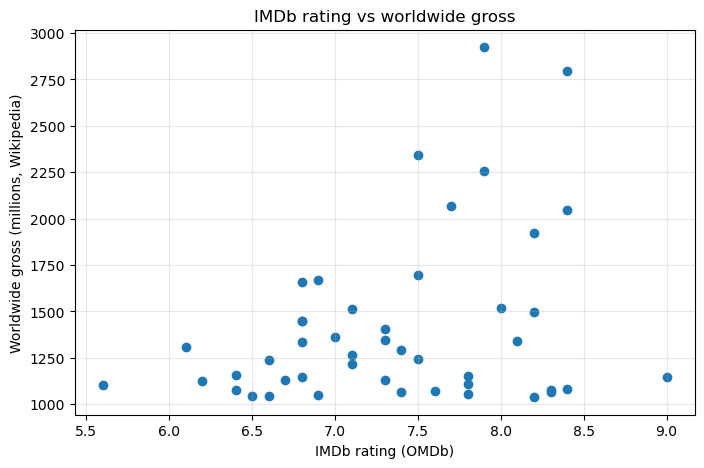

In [14]:
# Use only rows that have IMDb flat-file data
plot_df = master.dropna(subset=["imdb_title"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["imdb_rating"], plot_df["worldwide_gross_millions"])
plt.xlabel("IMDb rating (OMDb)")
plt.ylabel("Worldwide gross (millions, Wikipedia)")
plt.title("IMDb rating vs worldwide gross")
plt.grid(True, alpha=0.3)
plt.show()

## Visualization 2 - Metascore vs Rotten Tomatoes percentage

This visualization looks at how Metacritic scores (Metascore) align with
Rotten Tomatoes percentages for the same movies, both drawn from the OMDb API
data.

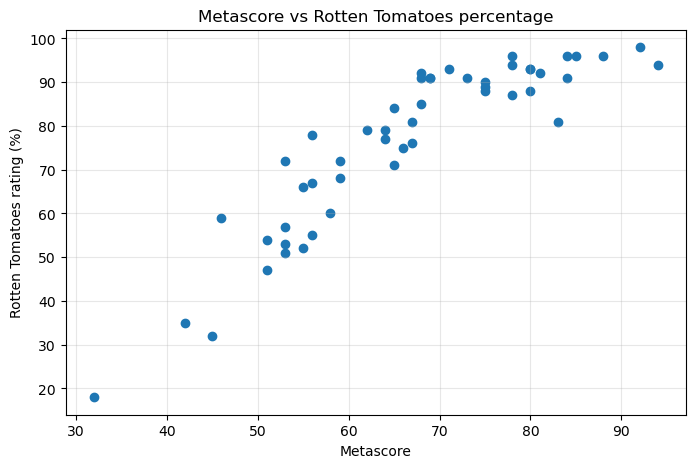

In [15]:
# Use only rows that have both Metascore and Rotten Tomatoes %
plot_df2 = master.dropna(subset=["metascore", "rt_rating_pct"])

plt.figure(figsize=(8, 5))
plt.scatter(plot_df2["metascore"], plot_df2["rt_rating_pct"])
plt.xlabel("Metascore")
plt.ylabel("Rotten Tomatoes rating (%)")
plt.title("Metascore vs Rotten Tomatoes percentage")
plt.grid(True, alpha=0.3)
plt.show()

## Visualization 3 - Box office compared to worldwide gross

Here I compare the OMDb `box_office_millions` values to the Wikipedia
`worldwide_gross_millions` for the same films. This shows where the OMDb box
office information lines up with, or diverges from, the Wikipedia totals.

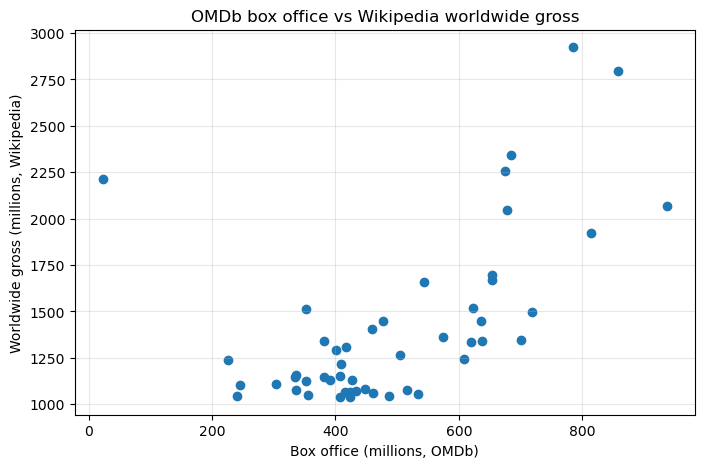

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(master["box_office_millions"], master["worldwide_gross_millions"])
plt.xlabel("Box office (millions, OMDb)")
plt.ylabel("Worldwide gross (millions, Wikipedia)")
plt.title("OMDb box office vs Wikipedia worldwide gross")
plt.grid(True, alpha=0.3)
plt.show()

## Visualization 4 - Average IMDb rating by decade

This bar chart aggregates the movies by decade and shows the average IMDb
rating for the highest grossing films released in each decade.

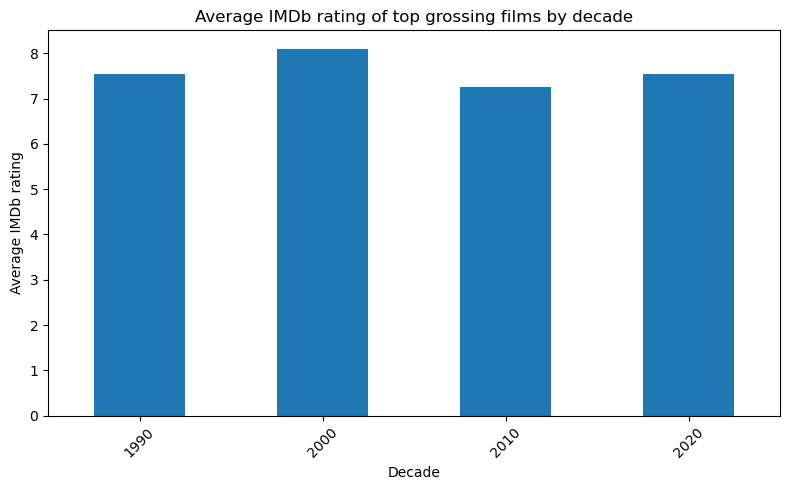

In [17]:
# Use only rows that have IMDb flat-file data
plot_df = master.dropna(subset=["imdb_title"])

decade_rating = (
    plot_df
    .dropna(subset=["decade", "imdb_rating"])
    .groupby("decade")["imdb_rating"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
decade_rating.plot(kind="bar")
plt.xlabel("Decade")
plt.ylabel("Average IMDb rating")
plt.title("Average IMDb rating of top grossing films by decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 5 - Count of movies by rating bucket

To understand how the IMDb ratings are distributed among these highest
grossing films, this chart counts how many movies fall into each rating
bucket (for example below 7.0, 7.0 - 7.4, and so on).

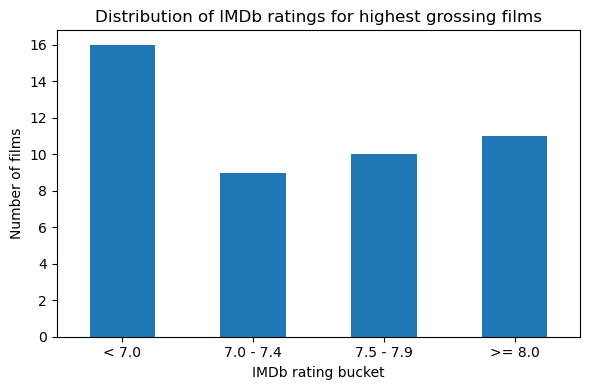

In [18]:
# Use only rows that have IMDb flat-file data
plot_df = master.dropna(subset=["imdb_title"])

bucket_counts = plot_df["rating_bucket"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
bucket_counts.plot(kind="bar")
plt.xlabel("IMDb rating bucket")
plt.ylabel("Number of films")
plt.title("Distribution of IMDb ratings for highest grossing films")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 7 - Summary and ethical considerations

For this milestone, I combined the three cleaned datasets created in earlier phases of the project: the IMDb flat file, the Wikipedia highest-grossing films table, and the OMDb API dataset. Each dataset had gone through its own cleaning and standardization process in previous milestones, so the focus here was on merging them in a structured, reproducible way and using SQL and visual analysis to explore the results.

I began by loading all three cleaned CSV files into a SQLite database. SQLite was a practical choice because it runs locally without configuration and supports full SQL syntax. Each dataset was written to its own table: imdb_movies, wikipedia_films, and omdb_api. After confirming the structure of the tables, I created a consolidated dataset using SQL joins. The primary join keys were title_norm plus release_year for the Wikipedia and OMDb tables, and a case-insensitive title plus release_year match for the IMDb flat file. The goal of the join was to combine box office performance (Wikipedia), industry metadata and ratings (OMDb), and user-generated IMDb data (flat file) into a single dataset for analysis.

Across the datasets, I applied transformations including title normalization, numeric parsing, handling of missing values, unit conversions such as converting gross earnings into millions, runtime extraction, and creation of consistent join keys. These changes ensured that the tables could be matched reliably and that the merged dataset would support accurate analysis.

Once merged, I added a small number of derived fields such as decade groupings and IMDb rating buckets. These made it easier to build the required five visualizations. The visualizations included comparisons of IMDb ratings to worldwide gross, Metascore to Rotten Tomatoes percentages, OMDb box office to Wikipedia totals, average rating by decade, and the distribution of IMDb rating buckets. Together, these charts highlight relationships between critic scores, audience ratings, and financial performance.

### Ethical Considerations

Several steps in this milestone have ethical implications. First, the project involves combining data from three different publicly available sources. While the data is not personal or sensitive, it is still important to cite sources and ensure that the use of the OMDb API respects its terms of service. None of the datasets contain personally identifiable information.

Because this project uses publicly available movie datasets, credibility was verified by cross-checking fields that appear in more than one source, including confirming IMDb IDs, titles, and release years between OMDb and the IMDb flat file whenever both sources had data.

The IMDb flat file dataset did not contain the most recent and upcoming films (for example Ne Zha 2, Deadpool & Wolverine, Moana 2, and Lilo & Stitch), so a small number of rows in the final merged dataset have missing IMDb flat-file columns while still retaining Wikipedia and OMDb information.

During visualization I identified one film with an unrealistically large worldwide gross value (around 82,000 million). Inspection of the cleaned Wikipedia column showed this was a parsing error, so I excluded values above a reasonable threshold from the charts to avoid a misleading outlier.

Some films appear as outliers on the far left of certain charts because OMDb's BoxOffice field only captures U.S. domestic gross and is often missing for older or internationally produced films. Wikipedia, however, provides worldwide totals. This naturally creates points with extremely low domestic revenue but very high global revenue.

Cleaning and transforming the data can introduce assumptions. For example, normalizing titles and correcting formatting required decisions about what constitutes equivalence between films. These choices affect the join results and therefore the visual conclusions. Another ethical consideration is ensuring that visualizations are not misleading. For example, scatter plots may imply causation when they only show correlation.

To mitigate risks, I documented every major transformation, used transparent cleaning rules, and designed visualizations that clearly label axes, units, and known data limitations. The final merged dataset and charts support analysis without misrepresenting the underlying data.